# 01 · 부채와 적립비율 — 부채는 할인된 약속

[![Colab에서 열기](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/keerhee/pension-fund-strategy-and-performance/blob/main/W06_LDI%EC%99%80GBI/W06_M7_%EC%8B%A4%EC%8A%B5_Colab/01_%EB%B6%80%EC%B1%84%EC%99%80_%EC%A0%81%EB%A6%BD%EB%B9%84%EC%9C%A8.ipynb)

**W06 M7 LDI 강의본 단원 ①(10~17장)** 과 도입의 메시지(5장)를 손계산 순서 그대로 재현합니다. 장 번호는 강의본 PDF 쪽번호(83장)입니다.

| 단계 | 강의 | 이 노트북에서 |
|---|---|---|
| 할인 = 복리를 거꾸로 | 12장 | 104 ÷ 1.04 = 100 · 108.16 ÷ 1.04² = 100 |
| 부채 = 할인된 약속 | 13장 | 3년간 매년 30, 할인율 4% → 28.85 · 27.74 · 26.67 · L = 83.25 · 연금현가 2.775 |
| 적립비율 · 잉여금 | 14 · 15장 | A 100 · L 80 → FR 125% · S 20 |
| 1년 뒤 적립비율 | 16장 | 자산 +7% · 부채 +10% → 107 ÷ 88 = 121.6%(정확) vs 121.25%(근사) · −3.4%p |
| 잉여금 수익률 | 17장 | R_S = r_A − (L/A) r_L = 7 − 8 = −1% · 잉여금 20 → 19 |
| "자산 +7.5%인데 나쁜 해" | 5 · 11장 | 자산 +7.5% · 부채 +15% → FR 하락 |

위에서부터 순서대로 실행하면 됩니다. 계산은 가벼워 몇 초 안에 끝납니다.

### 0. 준비 — 이 셀부터 실행
한글 폰트(Colab은 나눔고딕 설치, 맥은 Pretendard), 강의 색(잉크 · 라임 · 티일 · 빨강), 강의본 숫자 확인 함수 `check()`를 준비합니다.
`check(이름, 계산값, 강의값, 허용오차)`는 계산이 강의본 숫자와 허용오차 안에서 맞는지 확인하고, 틀리면 멈춥니다(`assert`).
가정을 바꿔 실험할 때는 `FAST = True`로 두면 확인이 멈추지 않고 ✗로 표시만 합니다(M7 세트는 계산이 가벼워 속도 차이는 없음).

In [1]:
# ── 환경 준비: 한글 폰트 · 강의 색 · 확인 함수 (이 셀을 먼저 실행) ──
import sys, os, glob, math, time, subprocess
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul")   # 맥 numpy(Accelerate)의 거짓 경고 — 결과와 무관
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"):
    # Colab: 나눔 폰트 설치 (= !apt-get -qq install -y fonts-nanum) — 처음 한 번 10초 안팎
    subprocess.run("apt-get -qq install -y fonts-nanum > /dev/null", shell=True)

def setup_korean_font():
    """로컬 맥은 Pretendard, Colab은 나눔고딕을 matplotlib에 등록한다(폰트 캐시 갱신과 같은 효과)."""
    files = (glob.glob(os.path.expanduser("~/Library/Fonts/Pretendard-*.otf"))
             + glob.glob("/Library/Fonts/Pretendard-*.otf")
             + glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"))
    for f in files:
        try:
            fm.fontManager.addfont(f)
        except Exception:
            pass
    names = {f.name for f in fm.fontManager.ttflist}
    for fam in ["Pretendard", "NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR"]:
        if fam in names:
            plt.rcParams["font.family"] = fam
            return fam
    return "(한글 폰트 없음 — 그래프 글자가 네모로 보이면 이 셀을 다시 실행)"

FONT = setup_korean_font()
plt.rcParams["axes.unicode_minus"] = False

# 강의 색 — 잉크 · 라임 · 티일 · 빨강 (+ 보조 회색 · 아이보리 바탕)
INK, LIME, TEAL, RED = "#071A1D", "#B7F34A", "#0B6B68", "#C00000"
GRAY, IVORY, OLIVE = "#8A9496", "#F7F5F0", "#5E8C1A"
plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": IVORY,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": "#DDD8CC", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "axes.axisbelow": True,
    "axes.prop_cycle": matplotlib.cycler(color=[TEAL, INK, RED, OLIVE, GRAY]),
})

# 빠른 모드 — M7 세트는 계산이 가벼워 FAST가 결과를 바꾸지 않는다. True면 확인(check)이 멈추지 않고 표시만 한다(숫자를 바꿔 실험할 때)
FAST = False

CHECKS = []
def check(label, value, lecture, tol, fmt=".4f", unit=""):
    """계산값을 강의본 숫자와 비교한다. 기본(재현) 모드에서는 허용오차를 넘으면 멈춘다(assert)."""
    ok = abs(value - lecture) <= tol + 1e-9      # 허용오차는 보통 강의 표기 자릿수의 반(반올림하면 같은 값)
    CHECKS.append((label, ok))
    print(f"{'✓' if ok else '✗'} {label}: 계산 {value:{fmt}}{unit} · 강의 {lecture:{fmt}}{unit} (허용 ±{tol:g})")
    if not FAST:
        assert ok, f"{label}: 계산 {value} · 강의 {lecture}"

print(f"Colab: {IN_COLAB} · 그래프 폰트: {FONT} · numpy {np.__version__} · matplotlib {matplotlib.__version__}")

Colab: False · 그래프 폰트: Pretendard · numpy 2.0.2 · matplotlib 3.9.4


## 1. 할인 — 복리로 불리기를 거꾸로 (강의 12장)
오늘 P를 금리 r로 t년 맡기면 P(1 + r)ᵗ. 거꾸로 t년 뒤의 금액 CF를 오늘 값으로 바꾸면 **PV = CF ÷ (1 + r)ᵗ** 입니다.
강의 숫자: 금리 4%에서 104 ÷ 1.04 = 100, 108.16 ÷ 1.04² = 100.

In [2]:
def pv(cf, r, t):
    """t년 뒤 cf의 현재가치 — 이산복리"""
    return cf / (1 + r) ** t

r = 0.04
print(f"100을 1년 맡기면 {100 * (1 + r):.2f} · 2년 맡기면 {100 * (1 + r)**2:.2f}")
print(f"거꾸로: 104 ÷ 1.04 = {pv(104, r, 1):.2f} · 108.16 ÷ 1.04² = {pv(108.16, r, 2):.2f}")
check("104 ÷ 1.04", pv(104, r, 1), 100, 0.005, ".2f")
check("108.16 ÷ 1.04²", pv(108.16, r, 2), 100, 0.005, ".2f")

100을 1년 맡기면 104.00 · 2년 맡기면 108.16
거꾸로: 104 ÷ 1.04 = 100.00 · 108.16 ÷ 1.04² = 100.00
✓ 104 ÷ 1.04: 계산 100.00 · 강의 100.00 (허용 ±0.005)
✓ 108.16 ÷ 1.04²: 계산 100.00 · 강의 100.00 (허용 ±0.005)


## 2. 연금 부채 = 해마다 줄 금액을 각각 할인해 더한 값 (강의 13장)
3년간 매년 30을 지급하고 할인율이 4%이면 L = 30/1.04 + 30/1.04² + 30/1.04³.
같은 금액이 반복되면 **연금현가 공식** L = CF × (1 − (1 + r)⁻ᵀ) ÷ r 로 한 번에 계산합니다.

In [3]:
CF, T = 30.0, 3
rows = [(t, CF, pv(CF, r, t)) for t in range(1, T + 1)]
print(f"{'시점':>6s} {'지급':>6s} {'현재가치':>9s}")
for t, c, v in rows:
    print(f"{t:>4d}년 {c:6.0f} {v:9.2f}")
L3 = sum(v for *_, v in rows)
annuity = (1 - (1 + r) ** -T) / r
print(f"합계 지급 {CF * T:.0f} → L = {L3:.2f} · 연금현가 계수 {annuity:.3f} × 30 = {CF * annuity:.2f}")
print(f"이자가 채우는 몫 = {CF * T - L3:.2f}")
for (t, _, v), lec in zip(rows, [28.85, 27.74, 26.67]):
    check(f"{t}년 뒤 30의 현재가치", v, lec, 0.005, ".2f")
check("부채 L (3년 연금)", L3, 83.25, 0.005, ".2f")
check("연금현가 계수", annuity, 2.775, 0.0005, ".3f")
check("이자가 채우는 몫", CF * T - L3, 6.75, 0.005, ".2f")

    시점     지급      현재가치
   1년     30     28.85
   2년     30     27.74
   3년     30     26.67
합계 지급 90 → L = 83.25 · 연금현가 계수 2.775 × 30 = 83.25
이자가 채우는 몫 = 6.75
✓ 1년 뒤 30의 현재가치: 계산 28.85 · 강의 28.85 (허용 ±0.005)
✓ 2년 뒤 30의 현재가치: 계산 27.74 · 강의 27.74 (허용 ±0.005)
✓ 3년 뒤 30의 현재가치: 계산 26.67 · 강의 26.67 (허용 ±0.005)
✓ 부채 L (3년 연금): 계산 83.25 · 강의 83.25 (허용 ±0.005)
✓ 연금현가 계수: 계산 2.775 · 강의 2.775 (허용 ±0.0005)
✓ 이자가 채우는 몫: 계산 6.75 · 강의 6.75 (허용 ±0.005)


**그래프 — 줄 금액과 그 현재가치.** 같은 30이라도 멀수록 오늘 값이 작습니다(막대의 빈 부분 = 이자가 채우는 몫).

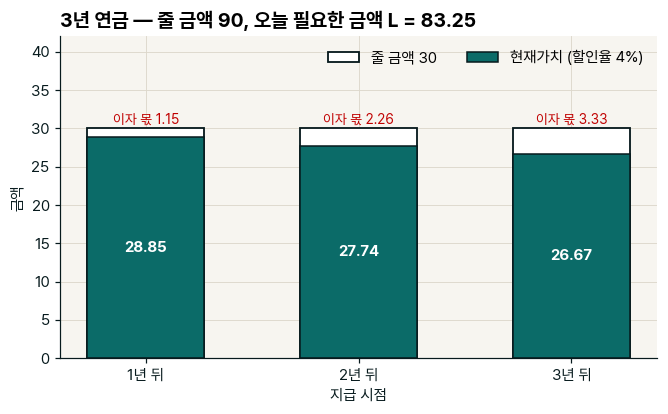

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.8))
ts = [t for t, *_ in rows]; pvs = [v for *_, v in rows]
ax.bar(ts, [CF] * T, 0.55, color="white", edgecolor=INK, lw=1.2, label="줄 금액 30")
ax.bar(ts, pvs, 0.55, color=TEAL, edgecolor=INK, label="현재가치 (할인율 4%)")
for t, v in zip(ts, pvs):
    ax.text(t, v / 2, f"{v:.2f}", ha="center", va="center", color="white", fontweight="bold")
    ax.text(t, CF + 0.6, f"이자 몫 {CF - v:.2f}", ha="center", fontsize=9, color=RED)
ax.set_xticks(ts, [f"{t}년 뒤" for t in ts]); ax.set_ylim(0, 42)
ax.set_ylabel("금액"); ax.set_xlabel("지급 시점")
ax.set_title(f"3년 연금 — 줄 금액 90, 오늘 필요한 금액 L = {L3:.2f}")
ax.legend(loc="upper right", ncol=2)
plt.show()

## 3. 적립비율과 잉여금 (강의 14 · 15장)
**적립비율 FR = A / L** (줄 금액의 몇 배를 가졌나), **잉여금 S = A − L** (버틸 여유). 강의 기금: 자산 A = 100, 부채 L = 80.
FR ≥ 100%면 적립, 미만이면 미적립입니다. ※ 국민연금이 공시하는 **적립배율**(적립금 ÷ 그해 지출)은 적립비율과 다른 지표입니다.

In [5]:
A0, L0 = 100.0, 80.0
FR0, S0 = A0 / L0, A0 - L0
print(f"A = {A0:.0f} · L = {L0:.0f} → FR = {FR0:.0%} · S = {S0:.0f} → {'적립' if FR0 >= 1 else '미적립'}")
check("적립비율 FR (%)", 100 * FR0, 125, 0.5, ".1f")
check("잉여금 S", S0, 20, 0.5, ".1f")

A = 100 · L = 80 → FR = 125% · S = 20 → 적립
✓ 적립비율 FR (%): 계산 125.0 · 강의 125.0 (허용 ±0.5)
✓ 잉여금 S: 계산 20.0 · 강의 20.0 (허용 ±0.5)


## 4. 1년 뒤 적립비율 — 자산 수익률에서 부채 수익률을 뺀 만큼 (강의 16장)
FR₁ = A(1 + r_A) ÷ L(1 + r_L) ≈ FR(1 + r_A − r_L), 즉 **ΔFR ≈ FR × (r_A − r_L)**.
r_L은 시간 이자와 금리 변화에 따른 재평가를 합친 부채의 변화율입니다. 자산 +7%, 부채 +10%이면?

In [6]:
rA, rL = 0.07, 0.10
A1, L1 = A0 * (1 + rA), L0 * (1 + rL)
FR1_exact = A1 / L1
FR1_approx = FR0 + FR0 * (rA - rL)
print(f"새 자산 {A1:.0f} · 새 부채 {L1:.0f}")
print(f"새 적립비율 (정확) {A1:.0f} ÷ {L1:.0f} = {FR1_exact:.1%}")
print(f"근사식 125% × (7% − 10%) = {FR0 * (rA - rL) * 100:+.2f}%p → {FR1_approx:.2%}")
print(f"7%를 벌고도 적립비율이 {100 * (FR0 - FR1_exact):.1f}%p 떨어졌다")
check("새 자산", A1, 107, 0.5, ".1f")
check("새 부채", L1, 88, 0.5, ".1f")
check("새 적립비율 정확 (%)", 100 * FR1_exact, 121.6, 0.05, ".2f")
check("근사 ΔFR (%p)", 100 * FR0 * (rA - rL), -3.75, 0.005, ".2f")
check("근사 적립비율 (%)", 100 * FR1_approx, 121.25, 0.005, ".2f")
check("적립비율 하락 (%p)", 100 * (FR0 - FR1_exact), 3.4, 0.05, ".2f")

새 자산 107 · 새 부채 88
새 적립비율 (정확) 107 ÷ 88 = 121.6%
근사식 125% × (7% − 10%) = -3.75%p → 121.25%
7%를 벌고도 적립비율이 3.4%p 떨어졌다
✓ 새 자산: 계산 107.0 · 강의 107.0 (허용 ±0.5)
✓ 새 부채: 계산 88.0 · 강의 88.0 (허용 ±0.5)
✓ 새 적립비율 정확 (%): 계산 121.59 · 강의 121.60 (허용 ±0.05)
✓ 근사 ΔFR (%p): 계산 -3.75 · 강의 -3.75 (허용 ±0.005)
✓ 근사 적립비율 (%): 계산 121.25 · 강의 121.25 (허용 ±0.005)
✓ 적립비율 하락 (%p): 계산 3.41 · 강의 3.40 (허용 ±0.05)


## 5. 성적표 한 숫자 — 잉여금 수익률 R_S (강의 17장)
잉여금 변화 = 자산이 번 금액 − 부채가 늘어난 금액. 이를 자산으로 나누면

**R_S = ΔS / A = r_A − (L/A) · r_L**

연기금의 성적표는 r_A가 아니라 R_S입니다.

In [7]:
def surplus_return(rA, rL, A, L):
    return rA - (L / A) * rL

RS = surplus_return(rA, rL, A0, L0)
S1 = A1 - L1
print(f"R_S = {rA:.0%} − ({L0 / A0:.1f}) × {rL:.0%} = {RS:+.1%}")
print(f"검산: 잉여금 {S0:.0f} → {S1:.0f} (= {A1:.0f} − {L1:.0f}), 변화 {S1 - S0:+.0f} = R_S × A {RS * A0:+.0f}")
check("L/A", L0 / A0, 0.8, 0.05, ".2f")
check("잉여금 수익률 R_S (%)", 100 * RS, -1, 0.5, ".2f")
check("1년 뒤 잉여금", S1, 19, 0.5, ".1f")

R_S = 7% − (0.8) × 10% = -1.0%
검산: 잉여금 20 → 19 (= 107 − 88), 변화 -1 = R_S × A -1
✓ L/A: 계산 0.80 · 강의 0.80 (허용 ±0.05)
✓ 잉여금 수익률 R_S (%): 계산 -1.00 · 강의 -1.00 (허용 ±0.5)
✓ 1년 뒤 잉여금: 계산 19.0 · 강의 19.0 (허용 ±0.5)


## 6. "자산 +7.5%인데 나쁜 해" (강의 5 · 11장)
할인율이 3% → 2%로 내려 부채가 +15% 늘어난 해. 운용역은 "자산 +7.5%"를 보고하고, 이사회는 "부채는 +15%"를 묻습니다.
같은 기금(A 100 · L 80)에 넣어 보면 적립비율과 잉여금 수익률은?

부채가 +15% 늘려면 듀레이션이 얼마여야 하나도 함께 봅니다 — 할인율 3% → 2%에서 t년 뒤 한 번 지급하는 약속은 (1.03/1.02)ᵗ배가 됩니다.

In [8]:
rA, rL = 0.075, 0.15
FR_b = A0 * (1 + rA) / (L0 * (1 + rL))
RS_b = surplus_return(rA, rL, A0, L0)
print(f"자산 +7.5% · 부채 +15% → FR {FR0:.0%} → {FR_b:.1%} ({100 * (FR_b - FR0):+.1f}%p) · R_S = {RS_b:+.1%}")
t15 = math.log(1.15) / math.log(1.03 / 1.02)
print(f"할인율 3% → 2%에 부채 +15%가 되는 단일 지급 시점 ≈ {t15:.1f}년 — 강의(5장)가 말하는 부채 듀레이션 15~25년의 아래쪽 끝")
check("자산 +7.5%여도 FR 하락", float(FR_b < FR0), 1, 0, ".0f")

자산 +7.5% · 부채 +15% → FR 125% → 116.8% (-8.2%p) · R_S = -4.5%
할인율 3% → 2%에 부채 +15%가 되는 단일 지급 시점 ≈ 14.3년 — 강의(5장)가 말하는 부채 듀레이션 15~25년의 아래쪽 끝
✓ 자산 +7.5%여도 FR 하락: 계산 1 · 강의 1 (허용 ±0)


## 7. 그래프 — 자산 수익률 · 부채 수익률 평면의 적립비율 변화
가로축 자산 수익률, 세로축 부채 수익률. 대각선(r_A = r_L) 위쪽은 적립비율이 나빠지는 영역입니다.
강의의 두 점(16장 · 11장)이 모두 "벌었지만 나쁜 해" 쪽에 있습니다.

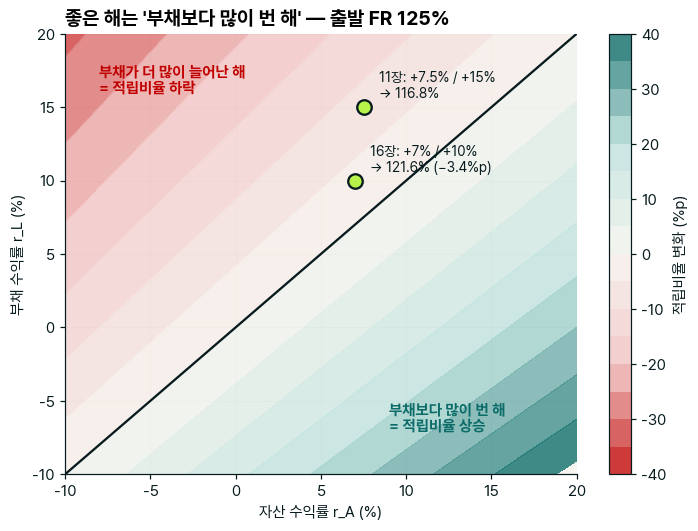

In [9]:
ra = np.linspace(-0.10, 0.20, 200); rl = np.linspace(-0.10, 0.20, 200)
RA, RL = np.meshgrid(ra, rl)
dFR = 100 * (A0 * (1 + RA) / (L0 * (1 + RL)) - FR0)
fig, ax = plt.subplots(figsize=(7.5, 5.2))
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("lec", [RED, "#F2C4C4", IVORY, "#BFE3DF", TEAL])
cs = ax.contourf(RA * 100, RL * 100, dFR, levels=np.arange(-40, 41, 5), cmap=cmap, alpha=0.85)
ax.contour(RA * 100, RL * 100, dFR, levels=[0], colors=INK, linewidths=1.5)
cb = fig.colorbar(cs, ax=ax); cb.set_label("적립비율 변화 (%p)")
for (x, y, lab) in [(7, 10, "16장: +7% / +10%\n→ 121.6% (−3.4%p)"), (7.5, 15, "11장: +7.5% / +15%\n→ " + f"{FR_b:.1%}")]:
    ax.scatter(x, y, s=90, color=LIME, edgecolor=INK, zorder=5, lw=1.5)
    ax.annotate(lab, (x, y), textcoords="offset points", xytext=(10, 6), fontsize=9, color=INK)
ax.text(-8, 16, "부채가 더 많이 늘어난 해\n= 적립비율 하락", color=RED, fontsize=10, fontweight="bold")
ax.text(9, -7, "부채보다 많이 번 해\n= 적립비율 상승", color=TEAL, fontsize=10, fontweight="bold")
ax.set_xlabel("자산 수익률 r_A (%)"); ax.set_ylabel("부채 수익률 r_L (%)")
ax.set_title("좋은 해는 '부채보다 많이 번 해' — 출발 FR 125%")
plt.show()

## 8. 정리
- 부채는 관찰되지 않고 **할인율로 추정되는 할인된 약속**입니다. 같은 약속도 할인율에 따라 크기가 달라집니다 → 02 노트북.
- 성적표는 r_A가 아니라 **R_S = r_A − (L/A) r_L**. 부채 수익률 r_L의 대부분은 금리 변화에서 옵니다 → 03 노트북의 듀레이션.

---
### 확인 결과 요약
이 노트북에서 강의본 숫자와 비교한 항목을 모아 봅니다. 모두 ✓이면 강의본 숫자를 그대로 재현한 것입니다.

In [10]:
# ── 확인 결과 요약 ──
n_ok = sum(ok for _, ok in CHECKS)
print(f"강의본 숫자 확인 {n_ok} / {len(CHECKS)} 통과" + (" — 빠른 모드라 일부 차이는 정상" if FAST else ""))
for label, ok in CHECKS:
    if not ok:
        print("  ✗", label)

강의본 숫자 확인 20 / 20 통과


---
## 바꿔 보기 (연습 문제)

1. 3년 연금(매년 30)을 할인율 3% · 5%로 다시 계산해 보라. 할인율 1%p가 부채를 몇 % 바꾸나? (`pv(30, 0.03, t)`)
2. 출발 FR이 80%(A 64 · L 80)인 기금이 자산 +7% · 부채 +10%를 겪으면 적립비율은 몇 %p 바뀌나? FR 125%일 때(−3.4%p)와 비교하라.
3. 잉여금 수익률이 0이 되려면 부채 +10%인 해에 자산이 몇 % 벌어야 하나? (`surplus_return(rA, 0.10, 100, 80) = 0`을 rA로 풀기)

아래 빈 셀에서 직접 해 보세요. 위 셀의 함수를 그대로 불러 쓰면 됩니다.

In [11]:
# 여기에 직접 해 보기

In [12]:
# 여기에 직접 해 보기

In [13]:
# 여기에 직접 해 보기